Vemos cual es nuestro directorio de trabajo para eso importamos el paquete **os** que tiene funciones para el sistema operativo.


In [1]:
import os # como se llama mi directorio de trabajo?
print(os.getcwd())

C:\Users\Debie\Dropbox\AustralPosgrado\DataScience


Cambio la carpeta de trabajo

In [2]:
os.chdir("C:/Users/Debie/Dropbox/AustralPosgrado/DataScience")

In [3]:
def open_close_plot(): 
    plt.show()
    plt.close()


In [10]:
import os
import mglearn
import pandas as pd
import numpy as np
from math import pi
import matplotlib.pyplot as plt 


make_blobs  GENERA DATOS ARTIFICIALES
Importa la función dendograma y la función Ward, single, complete,
average, linkage y la función fcluster clustering de scipy


In [11]:
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, ward, single, complete
from scipy.cluster.hierarchy import dendrogram, average, linkage, fcluster
from scipy.spatial.distance import pdist  


Simulación del cluster jerárquico

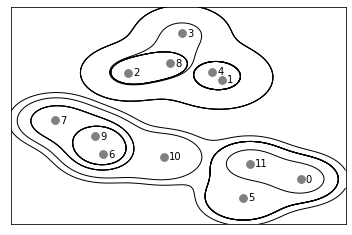

In [12]:
mglearn.plots.plot_agglomerative()   
open_close_plot()    

con éste lindo gráfico  muestra cómo se va formando el árbol binario de abajo 
hacia arriba.  

Primero el 4 y el 5; luego el 9 y el 6, etc


*Ejemplo 1. Datos simulados con dos variables*

In [13]:
x,y = make_blobs(random_state=0, n_samples=20, n_features=3)   
x=pd.DataFrame(x).abs()    
x.columns=["x1","x2","x3"]    
print(x)    


          x1        x2         x3
0   0.180614  0.131432   4.705366
1   1.146194  1.558149   2.778408
2   2.432693  0.960464   3.067147
3   0.409572  4.061638   3.569659
4   2.242389  3.797911   4.600468
5   1.555621  7.468936  10.392967
6   0.643213  4.351152   3.518008
7   0.707008  1.078266   1.925452
8   1.727676  8.146824   8.497235
9   1.706178  8.260853   9.245284
10  0.188137  0.887168   2.532019
11  0.328146  1.351517   2.455377
12  0.121901  0.531193   0.984677
13  0.794688  5.713992   1.680796
14  2.057082  4.788099   2.634408
15  1.009709  4.984355   0.491771
16  0.227734  8.482240   8.908921
17  1.474195  6.180889   8.633533
18  1.927033  7.481832   8.532508
19  1.251468  3.343033   2.432194


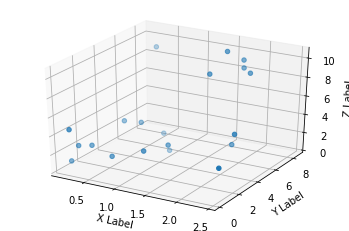

In [23]:
# This import registers the 3D projection, but is otherwise unused.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import

import matplotlib.pyplot as plt
import numpy as np

# Fijamos una semilla para que sea reproducible
np.random.seed(19680801)



fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

xs = x['x1']
ys = x['x2']
zs = x['x3']
ax.scatter(xs, ys, zs)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

Interesante: Python al conjunto de datos lo ve como para 
predecir por lo que me da la y 


Si imprimo y sale 0 1 y 2 como a los grupos a los que pertenecen los 20 individuos
Ve los segmentos como la variable a predecir


Utilizamos los métodos Ward,salto mínimo, salto máximo y promedio


In [14]:
ward_res=ward(x)    
single_res=single(x) 
complete_res= complete(x) 
average_res= average(x) 


Graficamos los dendogramas

En el paréntesis cuando escribimos *color_threshold=3* quiere decir que hace un corte en el valor de Y=3. 

**No quiere decir 3 colores**



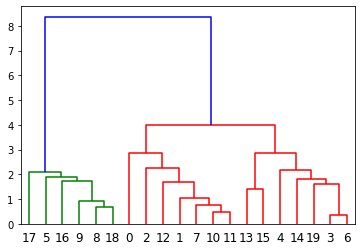

In [37]:
from scipy import cluster
cutree = cluster.hierarchy.cut_tree(average_res, n_clusters=3)

dendrogram(average_res, color_threshold=5)

open_close_plot()       



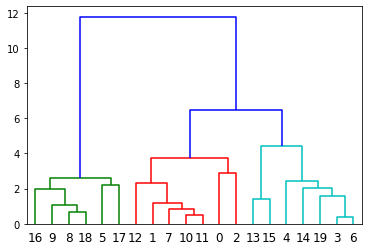

In [16]:
dendrogram(complete_res, color_threshold=5)
open_close_plot()


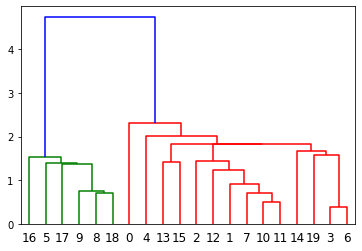

In [17]:
dendrogram(single_res)
open_close_plot()


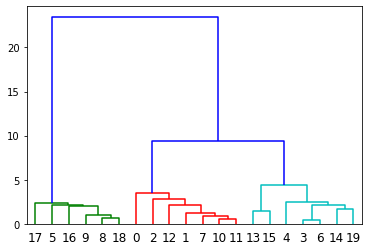

In [18]:
dendrogram(ward_res,color_threshold=5)
open_close_plot()


Agregar cortes con 2 o 3 clústeres

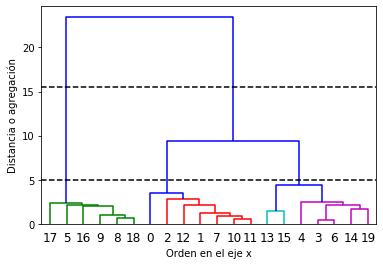

In [19]:
dendrogram(ward_res,color_threshold=3)
ax= plt.gca()
limites=ax.get_xbound()
ax.plot(limites,[15.5,15.5],linestyle='--',c='k')
ax.plot(limites,[5,5],linestyle='--',c='k')
plt.xlabel("Orden en el eje x")
plt.ylabel("Distancia o agregación")
open_close_plot()


vamos a interpretar los clústeres a través de
*Bar Plot*


Primero programamos una función que calcule los centros de los clústeres.
(veremos que k medias da los centros de gravedad pero noesta solución gráfica)
